# 6. Decision Trees and Ensemble Learning

## 6.1 Data cleaning and prep

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [5]:
df = pd.read_csv(data)

In [6]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

Convert the categorical variable values to their actual meanings. This is important to understand the data set we are working with.

In [10]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)

home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [11]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


Here, we see that the maximum value for income, assets, and det are 99999999 which is how the value was encoded to deal with missing value. We dont want them to interfer with the model so will replace the value with np.nan

In [13]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [14]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [15]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


Remove records where the target variable ('status') is unknow as we dont want these records.

In [17]:
df = df[df['status'] != 'unk'].reset_index(drop=True)

Now we do train test split to get the training data set, get the target variable out of the training data frame.

In [19]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [20]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [21]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [22]:
del df_train['status']
del df_val['status']
del df_test['status']

In [23]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,14,owner,60,30,married,no,fixed,60,70.0,4000.0,2800.0,600,1125
1,2,parents,60,35,married,no,fixed,75,104.0,0.0,0.0,1200,1677
2,8,rent,36,61,single,no,fixed,42,72.0,0.0,0.0,325,450
3,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
4,2,other,60,41,separated,no,freelance,35,100.0,5000.0,0.0,1200,1450


## 6.2 Decision Trees

In [25]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [26]:
xi = df_train.iloc[0].to_dict()

In [27]:
assess_risk(xi)

'default'

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [29]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [30]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [31]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [32]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

The problem with decision tree with infinite depth is that it is prone to overfitting. The algorithm will remember the data and failed to generalize when encountering new data set. As seen below, the score on training data set is almost 1 whereas the score of validation dataset is only 0.65

In [34]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.640131942005719

In [35]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.9999996473061242

We can control the max depth of the decision tree by tuning the hyper parameter of the DecisionTreeClassifier.

In [37]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [38]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7175133670978937
val: 0.7128913108914865


In [39]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- seniority <= 2.50
|   |--- records=no <= 0.50
|   |   |--- class: 1
|   |--- records=no >  0.50
|   |   |--- class: 0
|--- seniority >  2.50
|   |--- records=yes <= 0.50
|   |   |--- class: 0
|   |--- records=yes >  0.50
|   |   |--- class: 0



In this tree with max_depth = 2 (2 layers), the first node is seniority and split by threshold = 2.5. Any records with seniority <= 2.5 will be on the left df. Then the left df is further split by records = no. On the right df, the df is split by records = no as well.

## 6.3 Decision Tree Algorithm

- Structure of a decision tree: A decision tree is a data structure composed of nodes (which contains conditions) and branches (which represent the value of a condition True or False). The tree starts with a root node, which is a parent of two other nodes, and each of these nodes can also be split into 2 others nodes and so one. At the last level of the tree, there are terminal nodes and they are called leaves.

- Depth of a decision tree: the depth of a tree is the number of the levels it has, or simple the length of the longest path from the root node to a leaf node.

- Rules and conditions, thresholds: The learning algorithm for a decision tree involes determining the best conditions to split the data at each node in order to achive the best possible classifier. When there are many features, the algorithm considers each feature with its optimized threshold to determine the best feature for splitting at a particular node. In essence, at each node, the algorithm evaluates all possible thresholds for every feature and calcultes the resulting misclassification rate. It then selects the condition (feature and threshold) that yields the lowest impurity.

- Misclassification rate: After each split, the goal is to divide the data into two sets that are as pure as possible. This means that the data within each set should belong predominantly to either one class, or the other. Another way to desribe this is to aim for the lowest possible misclassification rate (impurity). The misclassification rate is a weighted average of the error rates obtained after splitting the data into two sets. The predicted class for each set is determined by the majority class present in the set.

- Impurity criteria: Common miscalssification rate measurements are GINI impurity and Entropy. It is also possible to use MSE for regression problems.

- Decision trees can also be used to solve regression problems.

- Stopping criteria: The process of recursively splitting the data at each child node eventuallyu stops based on certain stopping criteria. These criteria prevent the model from overfitting and include:

  - The group is already pure or impurity rate is 0%
  - The maximum depth is reached (tree max depth).
  - The group is smaller than the minimum size set (min sample leaf).
  - The maximum number of leaves/terminal nodes has been reached.

In [43]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [44]:
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
3,5000,ok
4,5000,ok
0,8000,default
6,9000,ok


In [45]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]

In [46]:
T = 4000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True))
display(df_right)
print(df_left.status.value_counts(normalize=True))

,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


## 6.4 Decision trees parameter tuning

**Fine Tuning Proces:** iterate over the two most importants parameters max_depths and min_samples_leaf:
- Start by tuning max_depth with various values to determine a subset of optimal depths
- Using the subset of max_depths, fine-tune the model further by iterating over possible min_samples_leaf values.

With a combination of max_depths and min_samples_leaf, we can control overfitting of the model. Max_depths limits the tree's complexity, preventing it from growing too deep and memorizing the training data. Min_samples_leaf ensures that leaf nodes have a sufficient number of samples, reducing the change of creating nodes that are too specific to the training data.

**Impact on Bias and Variance**:
- Increasing max_depth and decreasing min_sample_leaf can lead to a more complex model with lower bias (high training score) but higher variance (low validation / test score). The model is prone to overfitting and does not generalize well.
- Decreasing max_depth and increasing min_samples_leaf results in a simpler model with higher bias and lower variances (model can generalize better).

The goal of fine tunning is to fine the balance of this 2 parameters.

In [117]:
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print(f'{str(d):4s} -> {auc:.3f}')

1    -> 0.643
2    -> 0.713
3    -> 0.746
4    -> 0.755
5    -> 0.764
6    -> 0.763
10   -> 0.689
15   -> 0.651
20   -> 0.660
None -> 0.649


In [119]:
scores = []

for d in [4, 5, 6]:
    for s in [1, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, s, auc))

In [121]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [123]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.755  0.764  0.762
5                 0.755  0.768  0.775
10                0.753  0.768  0.779
15                0.762  0.775  0.784
20                0.762  0.766  0.778
100               0.762  0.769  0.770
200               0.754  0.759  0.760
500               0.697  0.697  0.697

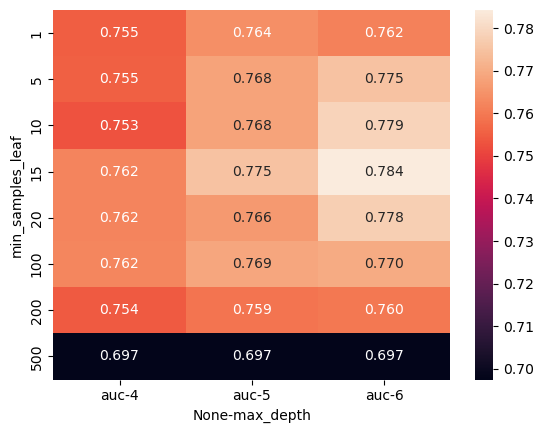

In [133]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")
plt.show()

In [135]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

## 6.5 Ensembles and random forest

**Ensemble learning** is a machine learning method where multiple models, often referred to as 'weak learners', are strategically combined to solve a particular computational intelligence problem. This approach ferquently yields superior predictive performance compared to using a single model.

**Random forest** is an example of ensemble learning in which each model is a decision tree and their predictions are aggregated to identify the most popular result. Random forest only selects a random subsets of features from the original data to make predictions. The randomness in RF stems from two key aspects:
- Each tree is potentially trained on a bootstrapped sample of the original data, introducing randomness at the row level.
- At each node during tree construction, only a random subset of features is considered for splitting. This feature randomness helps decorrelate the trees, preventing overfitting and promoting generalization to unseen data.

**Bootstrapping** is a resampling technique in which numerous subsets of the data are created by sampling the original data with replacement. This means that some data points may appear mutiple times in a single bootstrap samples and others may be excluded. In Random Forest, each decision tree is trained on a distinct bootstrap sample, further contributing to the diversisty and robustness of the ensemble.

**Parameter tuning** in RF is crucial to optimize the performance. Two critical parameters are max_depths, which controls the maximum depth of each decision tree, and n_estimators, which determines the number of trees in the forest. Increasing max_depth allows for more complex trees, potentially leading to overfitting. A larger n_estimators generally improve model accuracy at the expense of computational cost.

In [139]:
from sklearn.ensemble import RandomForestClassifier

In [141]:
scores = []

for n in range (10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state = 42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

In [143]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

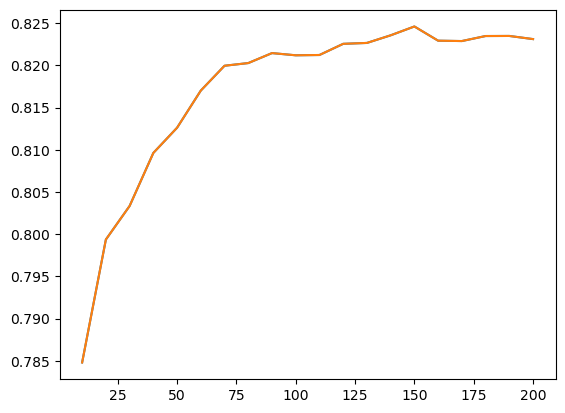

In [147]:
plt.plot(df_scores.n_estimators, df_scores.auc)
plt.show()

In [151]:
# fine-tuning max_depth and n_estimators

scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d,
                                    random_state = 42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
    
        scores.append((d, n, auc))

In [153]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

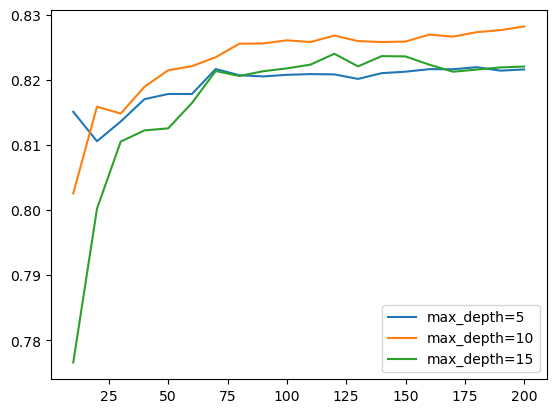

In [155]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)

plt.legend()
plt.show()

In [175]:
# model has the best performance when max_depth is 10
MAX_DEPTH = 10

In [159]:
# fine-tuning for min_samples_leaf

scores = []
for s in [1, 3, 5, 10, 20, 30, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state = 42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
    
        scores.append((s, n, auc))

In [161]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

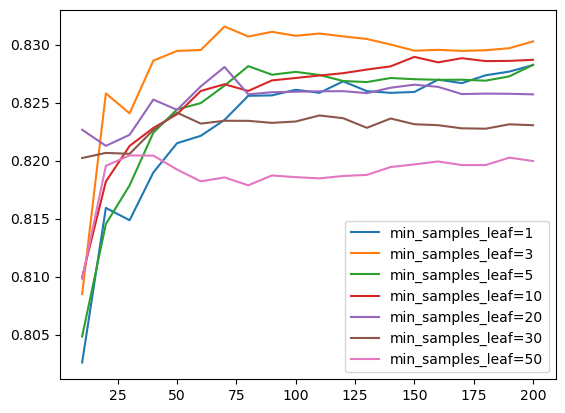

In [169]:
for s in [1, 3, 5, 10, 20, 30, 50]:
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='min_samples_leaf=%d' % s)

plt.legend()
plt.show()

In [173]:
MIN_SAMPLES_LEAF = 3

In [185]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=MAX_DEPTH,
                            min_samples_leaf=MIN_SAMPLES_LEAF,
                            bootstrap=True,
                            random_state=42)
rf.fit(X_train, y_train)
roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])

0.8302689008177395

In [187]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=MAX_DEPTH,
                            min_samples_leaf=MIN_SAMPLES_LEAF,
                            bootstrap=False,
                            random_state=1)
rf.fit(X_train, y_train)
roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])

0.8242236492249034

Using bootstrap to train the RF is slightly better.